In [1]:
%%capture
!pip install statsmodels

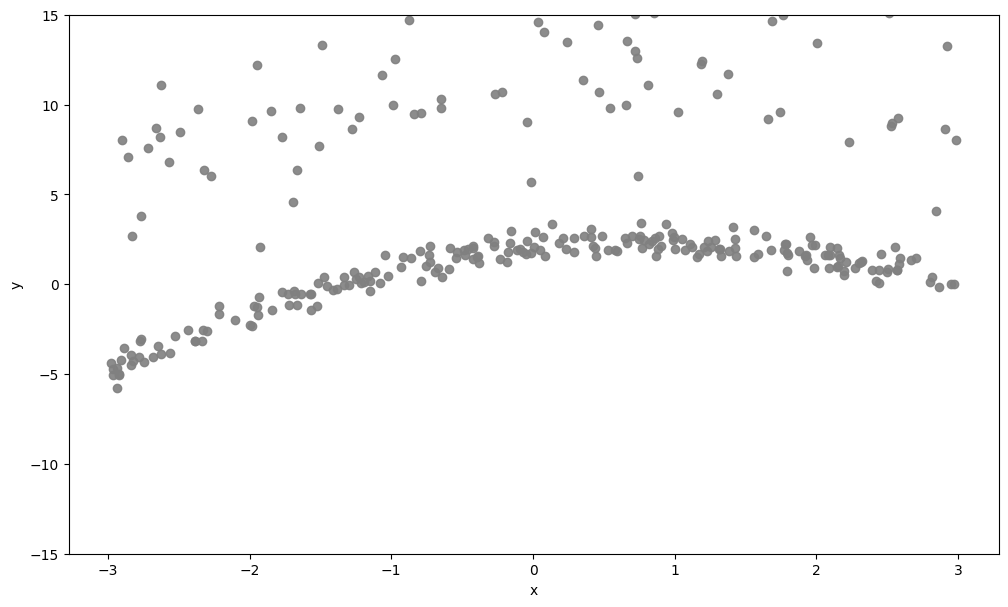

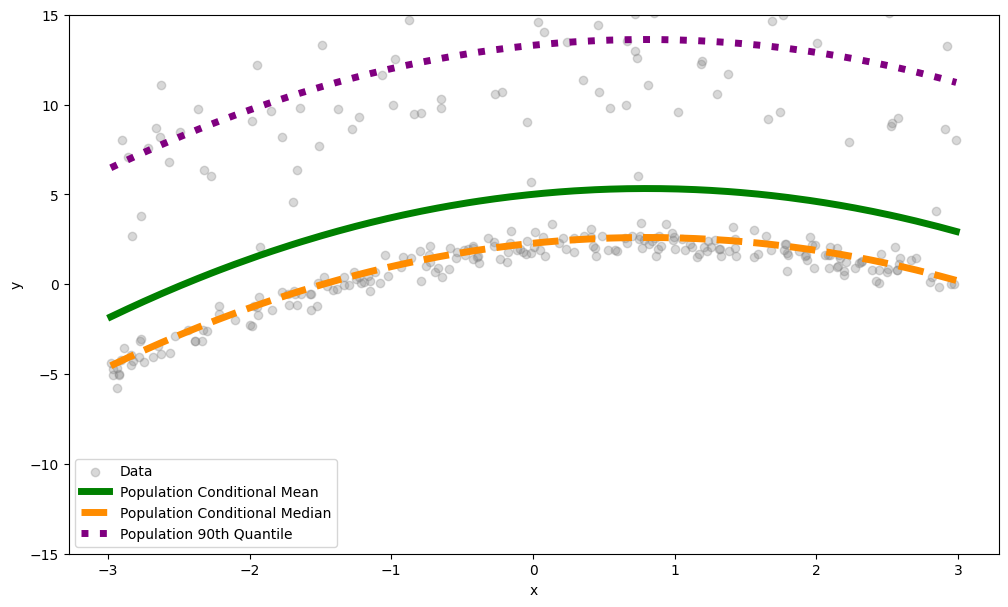

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

# Define the true underlying function f(x)
def f(x):
    return 2.0 + 0.8 * x - 0.5 * x**2

# Mixture parameters
p = 0.3  # probability of high-value component
# High-value component: Normal with mean=10, std=3
# Low-value component: Normal with mean=0, std=0.5

# Monte Carlo simulation to approximate noise population quantities:
N = 100000
r = np.random.rand(N)
noise_sample = np.where(r < p, 
                        np.random.normal(loc=10, scale=3, size=N), 
                        np.random.normal(loc=0, scale=0.5, size=N))
# Population moments and quantiles for the noise
pop_noise_mean = np.mean(noise_sample)
pop_noise_median = np.median(noise_sample)
pop_noise_q10 = np.percentile(noise_sample, 10)
pop_noise_q90 = np.percentile(noise_sample, 90)

# Generate synthetic x values and simulated responses
n = 300
x = np.sort(np.random.uniform(-3, 3, n))
# For visualization, generate one noise sample per x from the mixture
r_x = np.random.rand(n)
noise_x = np.where(r_x < p, 
                   np.random.normal(loc=10, scale=3, size=n), 
                   np.random.normal(loc=0, scale=0.5, size=n))
y = f(x) + noise_x

# Compute the population conditional curves
pop_cond_mean = f(x) + pop_noise_mean
pop_cond_median = f(x) + pop_noise_median
pop_cond_q10 = f(x) + pop_noise_q10
pop_cond_q90 = f(x) + pop_noise_q90

# -------------------------------
# Plotting the data
# -------------------------------
plt.figure(figsize=(12, 7))
# Scatter plot of the data
plt.scatter(x, y, color='#808080', alpha=0.9, label='Data')
plt.ylim(-15, 15)
plt.xlabel('x', color='#000000')
plt.ylabel('y', color='#000000')
plt.show()

# -------------------------------
# Plotting the results using the specified color palette
# -------------------------------
plt.figure(figsize=(12, 7))
# Scatter plot of the simulated data (Gray: #808080)
plt.scatter(x, y, color='#808080', alpha=0.3, label='Data')

# Plot the population conditional mean (Blue: #0000FF)
plt.plot(x, pop_cond_mean, color='#008000', linewidth=5, label='Population Conditional Mean')
# Plot the population conditional median (Dark Orange: #FF8C00)
plt.plot(x, pop_cond_median, color='#FF8C00', linestyle='--', linewidth=5, label='Population Conditional Median')
# Plot additional population quantile curves:
# 10th Quantile (Green: #008000)
# plt.plot(x, pop_cond_q10, color='#800080', linestyle=':', linewidth=5, label='Population 10th Quantile')
# 90th Quantile (Purple: #800080)
plt.plot(x, pop_cond_q90, color='#800080', linestyle=':', linewidth=5, label='Population 90th Quantile')

plt.ylim(-15, 15)
plt.xlabel('x', color='#000000')
plt.ylabel('y', color='#000000')
plt.legend()
plt.show()

Tuning regularization parameter (alpha):
  Alpha: 0.00010, Validation Loss: 1.63163
  Alpha: 0.00018, Validation Loss: 1.62570
  Alpha: 0.00032, Validation Loss: 1.65348
  Alpha: 0.00056, Validation Loss: 1.70537
  Alpha: 0.00100, Validation Loss: 1.59951
  Alpha: 0.00178, Validation Loss: 1.59853
  Alpha: 0.00316, Validation Loss: 1.59045
  Alpha: 0.00562, Validation Loss: 1.58204
  Alpha: 0.01000, Validation Loss: 1.58631
  Alpha: 0.01778, Validation Loss: 1.59153
  Alpha: 0.03162, Validation Loss: 1.60210
  Alpha: 0.05623, Validation Loss: 1.77796
  Alpha: 0.10000, Validation Loss: 1.58328
  Alpha: 0.17783, Validation Loss: 1.58328
  Alpha: 0.31623, Validation Loss: 1.58328
  Alpha: 0.56234, Validation Loss: 1.58328
  Alpha: 1.00000, Validation Loss: 1.58328
  Alpha: 1.77828, Validation Loss: 1.58328
  Alpha: 3.16228, Validation Loss: 1.58328
  Alpha: 5.62341, Validation Loss: 1.58328
  Alpha: 10.00000, Validation Loss: 1.58328

Best alpha selected: 0.00562 with validation loss: 1.5

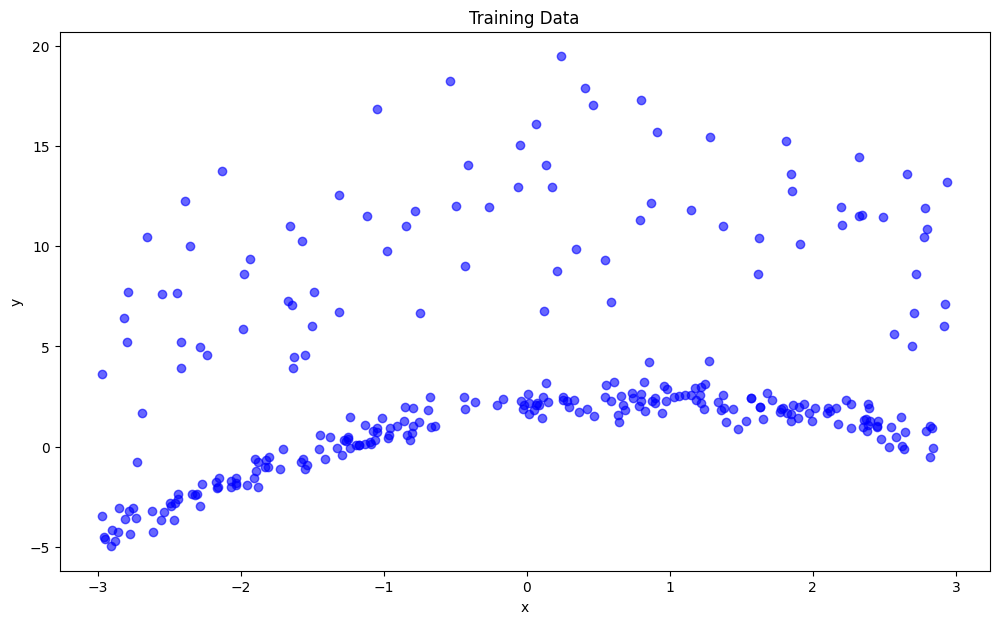

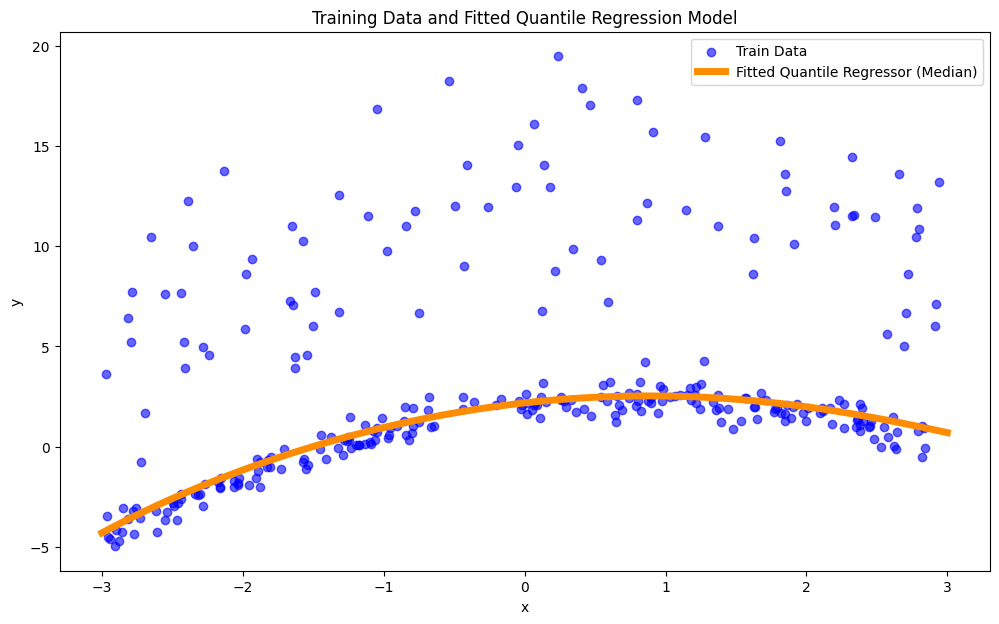

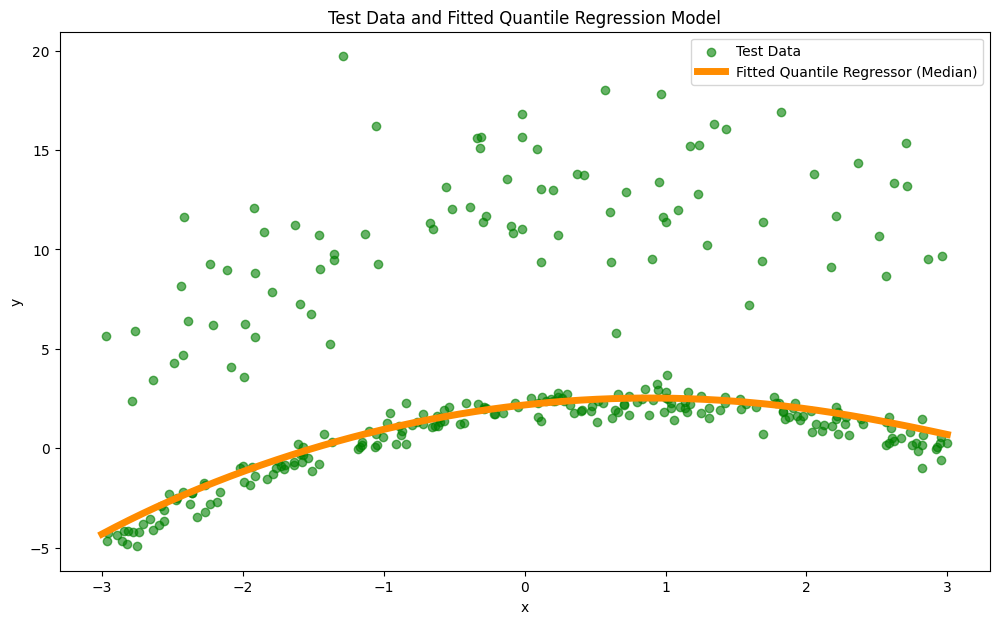

In [22]:
#%% [code]
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import QuantileRegressor

# ---------------------------
# 1. Set random seed for reproducibility
# ---------------------------
np.random.seed(42)

# ---------------------------
# 2. Define the underlying function and noise generator
# ---------------------------
def f(x):
    """True underlying quadratic function."""
    return 2.0 + 0.8 * x - 0.5 * x**2

p = 0.3  # probability for high-value noise component

def generate_noise(n, p):
    """Generate noise as a mixture:
       With probability p: Normal(mean=10, std=3);
       With probability (1-p): Normal(mean=0, std=0.5).
    """
    r = np.random.rand(n)
    noise = np.where(r < p, 
                     np.random.normal(loc=10, scale=3, size=n), 
                     np.random.normal(loc=0, scale=0.5, size=n))
    return noise

# ---------------------------
# 3. Generate train and test data
# ---------------------------
n_train = 300
n_test = 300

# Training data: x uniformly sampled in [-3, 3]
x_train = np.sort(np.random.uniform(-3, 3, n_train))
noise_train = generate_noise(n_train, p)
y_train = f(x_train) + noise_train

# Test data generation
x_test = np.sort(np.random.uniform(-3, 3, n_test))
noise_test = generate_noise(n_test, p)
y_test = f(x_test) + noise_test

# ---------------------------
# 4. Scale x values to [-1, 1] for numerical stability
# ---------------------------
x_train_scaled = x_train / 3
x_test_scaled = x_test / 3

# Split training data into training and validation sets (80/20 split)
split_idx = int(0.8 * n_train)
x_train_train = x_train[:split_idx]
y_train_train = y_train[:split_idx]
x_val = x_train[split_idx:]
y_val = y_train[split_idx:]

# Scale the split data
x_train_train_scaled = x_train_train / 3
x_val_scaled = x_val / 3

# ---------------------------
# 5. Prepare polynomial features
# ---------------------------
poly = PolynomialFeatures(degree=20, include_bias=True)
X_train_train = poly.fit_transform(x_train_train_scaled.reshape(-1, 1))
X_val = poly.transform(x_val_scaled.reshape(-1, 1))
X_train_full = poly.transform(x_train_scaled.reshape(-1, 1))
X_test = poly.transform(x_test_scaled.reshape(-1, 1))

# ---------------------------
# 6. Regularized Polynomial Quantile Regression (Median)
# ---------------------------
tau = 0.5  # target quantile (median)

# Candidate regularization coefficients (alpha)
alphas = np.logspace(-4, 1, 21)
best_alpha = None
best_loss = np.inf
best_model = None

def pinball_loss(y_true, y_pred, tau):
    """Compute the pinball loss for quantile regression."""
    diff = y_true - y_pred
    return np.mean(np.maximum(tau * diff, (tau - 1) * diff))

print("Tuning regularization parameter (alpha):")
for alpha in alphas:
    model = QuantileRegressor(quantile=tau, alpha=alpha, solver='highs', fit_intercept=True)
    model.fit(X_train_train, y_train_train)
    y_val_pred = model.predict(X_val)
    loss = pinball_loss(y_val, y_val_pred, tau)
    print(f"  Alpha: {alpha:.5f}, Validation Loss: {loss:.5f}")
    if loss < best_loss:
        best_loss = loss
        best_alpha = alpha
        best_model = model

print(f"\nBest alpha selected: {best_alpha:.5f} with validation loss: {best_loss:.5f}")

# Refit on the full training data using the best alpha
final_model = QuantileRegressor(quantile=tau, alpha=best_alpha, solver='highs', fit_intercept=True)
final_model.fit(X_train_full, y_train)

# ---------------------------
# 7. Generate predictions for plotting the regression curve
# ---------------------------
x_grid = np.linspace(-3, 3, 500)
x_grid_scaled = x_grid / 3
X_grid = poly.transform(x_grid_scaled.reshape(-1, 1))
y_grid_pred = final_model.predict(X_grid)

# ---------------------------
# 8. Define color palette based on your preferred colors
# ---------------------------
# Using color palette:
#   Gray (#808080)
#   Blue (#0000FF)
#   Dark Orange (#FF8C00)
color_train = "#0000FF"       # Gray
color_regressor = "#FF8C00"        # Dark Orange
color_test = "#008000"   # Blue

# ---------------------------
# 9. Plot training data alone
# ---------------------------
plt.figure(figsize=(12, 7))
plt.scatter(x_train, y_train, color=color_train, alpha=0.6, label='Train Data')
plt.xlabel('x', color="#000000")
plt.ylabel('y', color="#000000")
plt.title('Training Data', color="#000000")
plt.show()

# ---------------------------
# 9. Plot training data with the fitted regression curve
# ---------------------------
plt.figure(figsize=(12, 7))
plt.scatter(x_train, y_train, color=color_train, alpha=0.6, label='Train Data')
plt.plot(x_grid, y_grid_pred, color=color_regressor, linewidth=5, label='Fitted Quantile Regressor (Median)')
plt.xlabel('x', color="#000000")
plt.ylabel('y', color="#000000")
plt.title('Training Data and Fitted Quantile Regression Model', color="#000000")
plt.legend()
plt.show()

# ---------------------------
# 10. Plot test data with the trained model
# ---------------------------
plt.figure(figsize=(12, 7))
plt.scatter(x_test, y_test, color=color_test, alpha=0.6, label='Test Data')
plt.plot(x_grid, y_grid_pred, color=color_regressor, linewidth=5, label='Fitted Quantile Regressor (Median)')
plt.xlabel('x', color="#000000")
plt.ylabel('y', color="#000000")
plt.title('Test Data and Fitted Quantile Regression Model', color="#000000")
plt.legend()
plt.show()

Tuning regularization parameter (alpha):
  Alpha: 0.00010, Validation Loss: 1.63163
  Alpha: 0.00018, Validation Loss: 1.62570
  Alpha: 0.00032, Validation Loss: 1.65348
  Alpha: 0.00056, Validation Loss: 1.70537
  Alpha: 0.00100, Validation Loss: 1.59951
  Alpha: 0.00178, Validation Loss: 1.59853
  Alpha: 0.00316, Validation Loss: 1.59045
  Alpha: 0.00562, Validation Loss: 1.58204
  Alpha: 0.01000, Validation Loss: 1.58631
  Alpha: 0.01778, Validation Loss: 1.59153
  Alpha: 0.03162, Validation Loss: 1.60210
  Alpha: 0.05623, Validation Loss: 1.77796
  Alpha: 0.10000, Validation Loss: 1.58328
  Alpha: 0.17783, Validation Loss: 1.58328
  Alpha: 0.31623, Validation Loss: 1.58328
  Alpha: 0.56234, Validation Loss: 1.58328
  Alpha: 1.00000, Validation Loss: 1.58328
  Alpha: 1.77828, Validation Loss: 1.58328
  Alpha: 3.16228, Validation Loss: 1.58328
  Alpha: 5.62341, Validation Loss: 1.58328
  Alpha: 10.00000, Validation Loss: 1.58328

Best alpha selected: 0.00562 with validation loss: 1.5

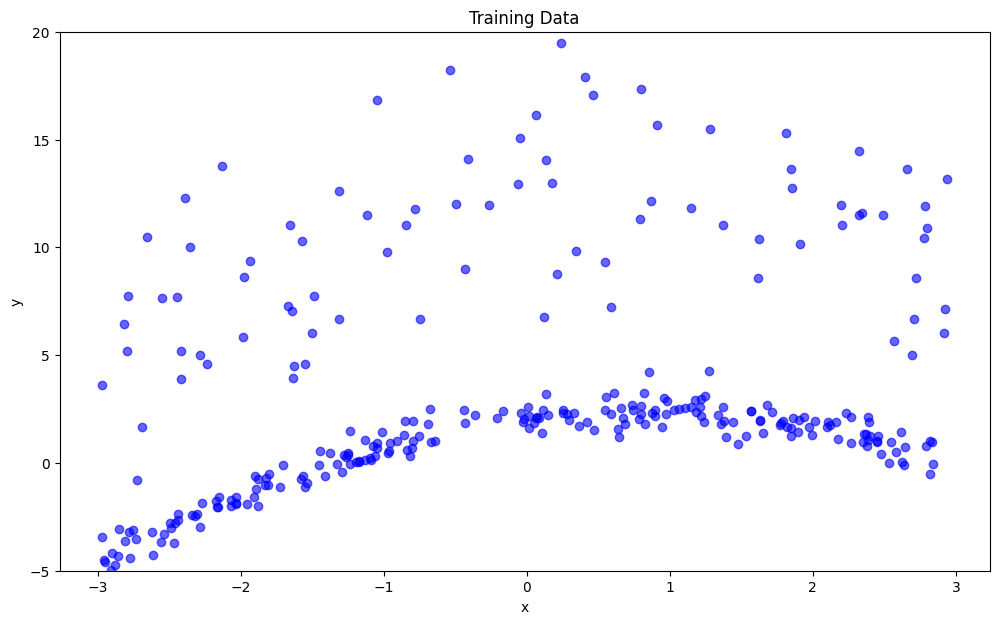

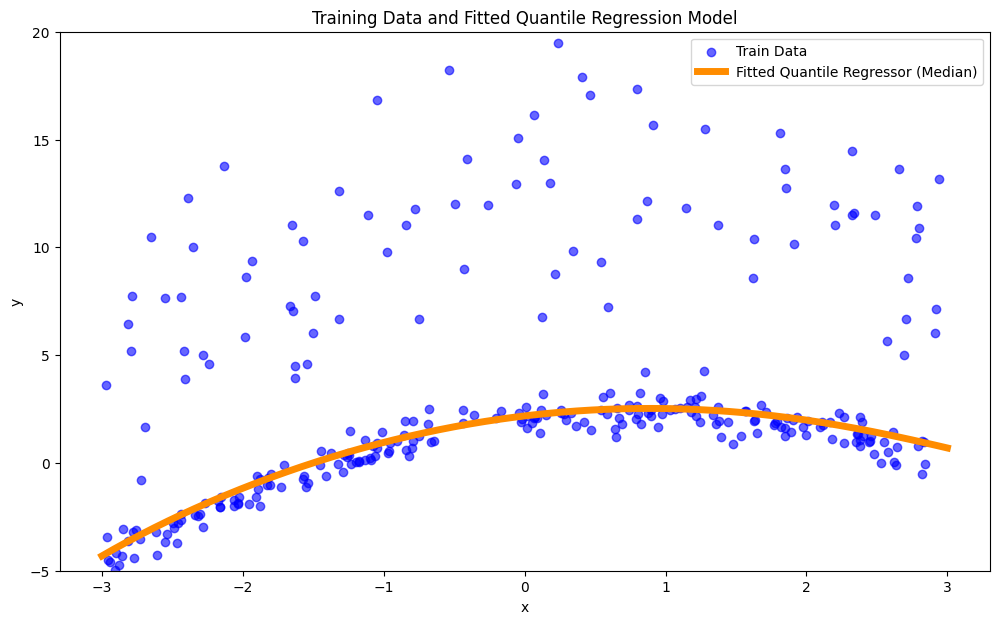

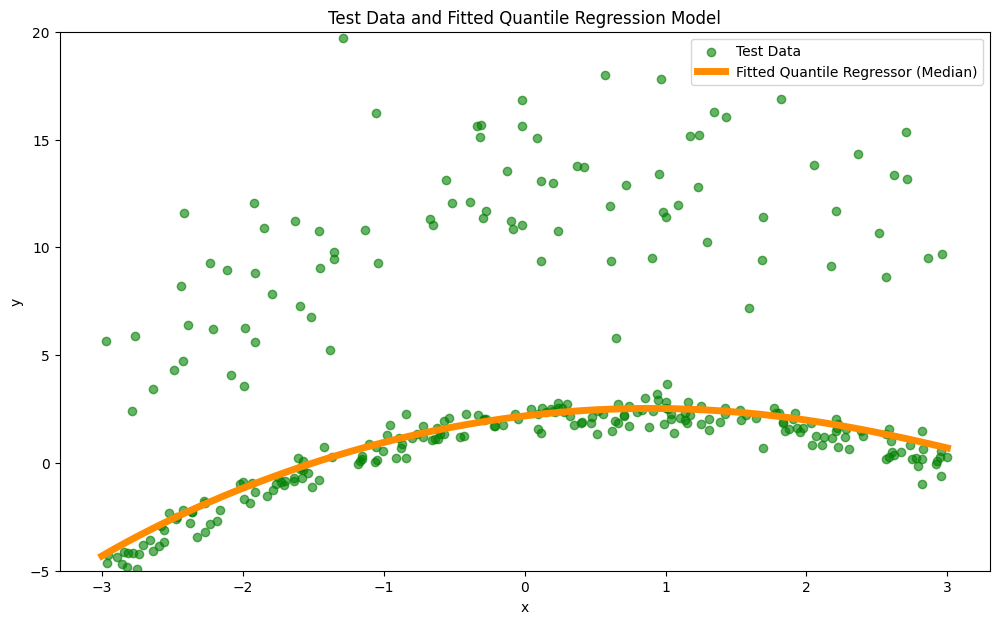

Computed noise median: 0.283


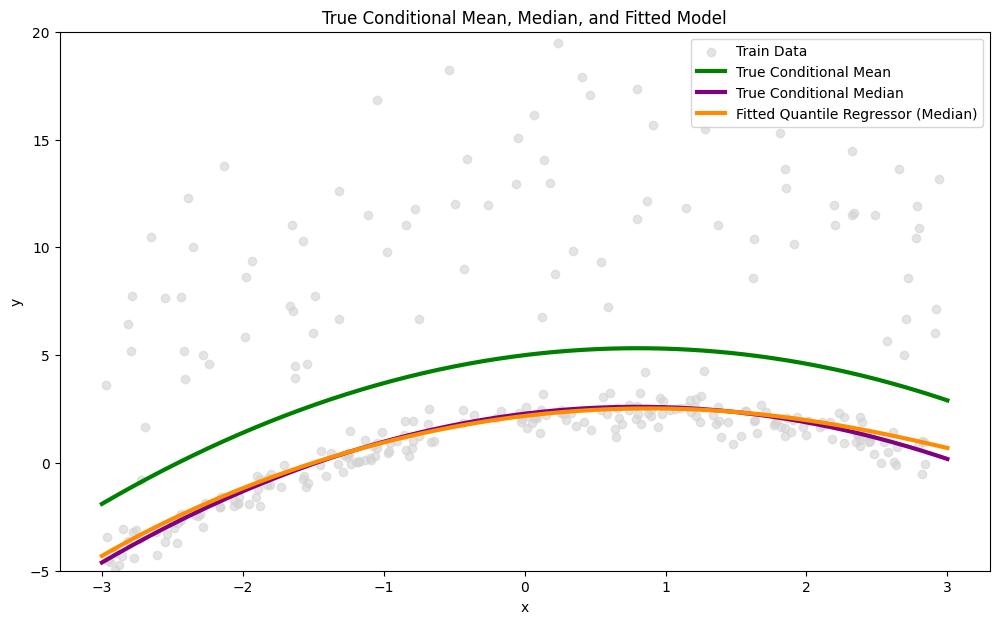

In [28]:
#%% [code]
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import QuantileRegressor
from scipy.stats import norm
from scipy.optimize import bisect

# ---------------------------
# 1. Set random seed for reproducibility
# ---------------------------
np.random.seed(42)

# ---------------------------
# 2. Define the underlying function and noise generator
# ---------------------------
def f(x):
    """True underlying quadratic function."""
    return 2.0 + 0.8 * x - 0.5 * x**2

p = 0.3  # probability for high-value noise component

def generate_noise(n, p):
    """Generate noise as a mixture:
       With probability p: Normal(mean=10, std=3);
       With probability (1-p): Normal(mean=0, std=0.5).
    """
    r = np.random.rand(n)
    noise = np.where(r < p, 
                     np.random.normal(loc=10, scale=3, size=n), 
                     np.random.normal(loc=0, scale=0.5, size=n))
    return noise

# ---------------------------
# 3. Generate train and test data
# ---------------------------
n_train = 300
n_test = 300

# Training data: x uniformly sampled in [-3, 3]
x_train = np.sort(np.random.uniform(-3, 3, n_train))
noise_train = generate_noise(n_train, p)
y_train = f(x_train) + noise_train

# Test data generation
x_test = np.sort(np.random.uniform(-3, 3, n_test))
noise_test = generate_noise(n_test, p)
y_test = f(x_test) + noise_test

# ---------------------------
# 4. Scale x values to [-1, 1] for numerical stability
# ---------------------------
x_train_scaled = x_train / 3
x_test_scaled = x_test / 3

# Split training data into training and validation sets (80/20 split)
split_idx = int(0.8 * n_train)
x_train_train = x_train[:split_idx]
y_train_train = y_train[:split_idx]
x_val = x_train[split_idx:]
y_val = y_train[split_idx:]

# Scale the split data
x_train_train_scaled = x_train_train / 3
x_val_scaled = x_val / 3

# ---------------------------
# 5. Prepare polynomial features
# ---------------------------
poly = PolynomialFeatures(degree=20, include_bias=True)
X_train_train = poly.fit_transform(x_train_train_scaled.reshape(-1, 1))
X_val = poly.transform(x_val_scaled.reshape(-1, 1))
X_train_full = poly.transform(x_train_scaled.reshape(-1, 1))
X_test = poly.transform(x_test_scaled.reshape(-1, 1))

# ---------------------------
# 6. Regularized Polynomial Quantile Regression (Median)
# ---------------------------
tau = 0.5  # target quantile (median)

# Candidate regularization coefficients (alpha)
alphas = np.logspace(-4, 1, 21)
best_alpha = None
best_loss = np.inf
best_model = None

def pinball_loss(y_true, y_pred, tau):
    """Compute the pinball loss for quantile regression."""
    diff = y_true - y_pred
    return np.mean(np.maximum(tau * diff, (tau - 1) * diff))

print("Tuning regularization parameter (alpha):")
for alpha in alphas:
    model = QuantileRegressor(quantile=tau, alpha=alpha, solver='highs', fit_intercept=True)
    model.fit(X_train_train, y_train_train)
    y_val_pred = model.predict(X_val)
    loss = pinball_loss(y_val, y_val_pred, tau)
    print(f"  Alpha: {alpha:.5f}, Validation Loss: {loss:.5f}")
    if loss < best_loss:
        best_loss = loss
        best_alpha = alpha
        best_model = model

print(f"\nBest alpha selected: {best_alpha:.5f} with validation loss: {best_loss:.5f}")

# Refit on the full training data using the best alpha
final_model = QuantileRegressor(quantile=tau, alpha=best_alpha, solver='highs', fit_intercept=True)
final_model.fit(X_train_full, y_train)

# ---------------------------
# 7. Generate predictions for plotting the regression curve
# ---------------------------
x_grid = np.linspace(-3, 3, 500)
x_grid_scaled = x_grid / 3
X_grid = poly.transform(x_grid_scaled.reshape(-1, 1))
y_grid_pred = final_model.predict(X_grid)

# ---------------------------
# 8. Define color palette based on your preferred colors
# ---------------------------
color_train = "#0000FF"       # Blue for train data
color_regressor = "#FF8C00"   # Dark Orange for model curve
color_test = "#008000"        # Green for test data
color_grayout = "#D3D3D3"

ylim = (-5, 20)

# ---------------------------
# 9. Plot training data alone
# ---------------------------
plt.figure(figsize=(12, 7))
plt.scatter(x_train, y_train, color=color_train, alpha=0.6, label='Train Data')
plt.ylim(*ylim)
plt.xlabel('x', color="#000000")
plt.ylabel('y', color="#000000")
plt.title('Training Data', color="#000000")
plt.show()

# ---------------------------
# 10. Plot training data with the fitted regression curve
# ---------------------------
plt.figure(figsize=(12, 7))
plt.scatter(x_train, y_train, color=color_train, alpha=0.6, label='Train Data')
plt.plot(x_grid, y_grid_pred, color=color_regressor, linewidth=5, label='Fitted Quantile Regressor (Median)')
plt.ylim(*ylim)
plt.xlabel('x', color="#000000")
plt.ylabel('y', color="#000000")
plt.title('Training Data and Fitted Quantile Regression Model', color="#000000")
plt.legend()
plt.show()

# ---------------------------
# 11. Plot test data with the trained model
# ---------------------------
plt.figure(figsize=(12, 7))
plt.scatter(x_test, y_test, color=color_test, alpha=0.6, label='Test Data')
plt.plot(x_grid, y_grid_pred, color=color_regressor, linewidth=5, label='Fitted Quantile Regressor (Median)')
plt.ylim(*ylim)
plt.xlabel('x', color="#000000")
plt.ylabel('y', color="#000000")
plt.title('Test Data and Fitted Quantile Regression Model', color="#000000")
plt.legend()
plt.show()

# ---------------------------
# 12. Compute true conditional mean and median
# ---------------------------
# True conditional mean: f(x) + p * 10
def true_mean(x):
    return f(x) + p * 10

# For the true conditional median, we need to compute the median of the noise mixture.
def find_noise_median(p, mu_high, sigma_high, mu_low, sigma_low):
    """
    Solve for t such that:
      (1-p)*Phi(t/sigma_low) + p*Phi((t-mu_high)/sigma_high) = 0.5,
    where Phi is the standard normal CDF.
    """
    def func(t):
        return (1-p) * norm.cdf(t / sigma_low) + p * norm.cdf((t - mu_high) / sigma_high) - 0.5
    # Provide a bracket that should contain the median.
    return bisect(func, -5, mu_high + 3*sigma_high)

# Compute the median of the noise distribution.
median_noise = find_noise_median(p, mu_high=10, sigma_high=3, mu_low=0, sigma_low=0.5)
print(f"Computed noise median: {median_noise:.3f}")

def true_median(x):
    return f(x) + median_noise

# ---------------------------
# 13. Plot true conditional mean, true conditional median, and the trained model
# ---------------------------
plt.figure(figsize=(12, 7))
plt.scatter(x_train, y_train, color=color_grayout, alpha=0.6, label='Train Data')
plt.plot(x_grid, true_mean(x_grid), label='True Conditional Mean', color='#008000', linewidth=3)
plt.plot(x_grid, true_median(x_grid), label='True Conditional Median', color='#800080', linewidth=3)
plt.plot(x_grid, y_grid_pred, label='Fitted Quantile Regressor (Median)', color=color_regressor, linewidth=3)
plt.ylim(*ylim)
plt.xlabel('x', color="#000000")
plt.ylabel('y', color="#000000")
plt.title('True Conditional Mean, Median, and Fitted Model', color="#000000")
plt.legend()
plt.show()